# AccelP3 — Feature Engineering & Survival Modelling
**Pipeline: CSV → Feature Extraction → Leakage Audit → LOTO Cox PH → Results**

This notebook documents the feature engineering and modelling workflow using pre-extracted CSV inputs.  
The private PDF extraction pipeline is not included in this public repository.

| Step | Description |
|------|-------------|
| 0 | Setup & data loading |
| 1 | Data validation (KM median vs PDF ground truth) |
| 2 | Feature engineering — leakage-free fixed window |
| 3 | Leakage audit |
| 4 | LOTO Cox PH model |
| 5 | Results & visualisation |


## Step 0 — Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.utils import concordance_index
from sklearn.model_selection import StratifiedKFold

warnings.filterwarnings('ignore')
sns.set_theme(style='ticks', font_scale=1.1)

# ── Paths ──────────────────────────────────────────────────────────────────
NOTEBOOK_DIR = Path(__file__).resolve().parent if '__file__' in dir() else Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
DATA_DIR     = PROJECT_ROOT / 'data'

MASTER_PATH  = DATA_DIR / 'master_dataset.csv'
TS_DIR       = DATA_DIR / 'timeseries'

TRIALS = ['WV15670', 'WV15671', 'M76001', 'WV15812', 'WV15819', 'WV16277']

print("Project setup complete.")
print("Expected local input directory: data/")


Project setup complete.
Expected local input directory: data/


### Load master dataset & symptom timeseries

In [2]:
# ── Master dataset (TTA labels + baseline features) ────────────────────────
master = pd.read_csv(MASTER_PATH)
print(f"master_dataset: {master.shape}")
print(f"  Trials: {master['trial_id'].value_counts().to_dict()}")
print(f"  Treatment arms: {master['treatment'].value_counts().to_dict()}")
print(f"  Event rate: {master['event'].mean():.1%}  |  Censored: {master['censored'].mean():.1%}")
print(f"  TTA range: {master['tta_hours'].min():.0f}–{master['tta_hours'].max():.0f}h")


master_dataset: (4123, 20)
  Trials: {'M76001': 1373, 'WV15819': 708, 'WV15670': 606, 'WV15671': 595, 'WV16277': 445, 'WV15812': 396}
  Treatment arms: {'Oseltamivir_75mg': 2103, 'Placebo': 1633, 'Oseltamivir_150mg': 387}
  Event rate: 91.5%  |  Censored: 8.5%
  TTA range: 4–480h


In [3]:
# ── Symptom timeseries (all 6 trials) ──────────────────────────────────────
# NOTE: subject_id is NOT globally unique across trials.
#       Always use (trial_id, subject_id) as composite key.

ts_frames = []
for trial in TRIALS:
    path = TS_DIR / f'{trial}_symptom_timeseries.csv'
    df = pd.read_csv(path)
    # Ensure trial_id column exists
    if 'trial_id' not in df.columns:
        df['trial_id'] = trial
    # Safety clip: total_symptom_score must be in [0, 21]
    # (7 symptoms × max score 3 = 21)
    df['total_symptom_score'] = df['total_symptom_score'].clip(0, 21)
    ts_frames.append(df)
    print(f"  {trial}: {len(df):>6} rows  |  "
          f"score range [{df['total_symptom_score'].min():.1f}, "
          f"{df['total_symptom_score'].max():.1f}]")

ts_all = pd.concat(ts_frames, ignore_index=True)
print(f"\nCombined timeseries: {len(ts_all):,} rows across {ts_all['trial_id'].nunique()} trials")


  WV15670:  11646 rows  |  score range [0.0, 21.0]
  WV15671:  10770 rows  |  score range [0.0, 21.0]
  M76001:  53872 rows  |  score range [0.0, 21.0]
  WV15812:  15735 rows  |  score range [0.0, 21.0]
  WV15819:  28725 rows  |  score range [0.0, 21.0]
  WV16277:  17966 rows  |  score range [0.0, 21.0]



Combined timeseries: 138,714 rows across 6 trials


## Step 1 — Data Validation

Cross-validate our KM medians against PDF CSR ground truth.

**PDF ground truth sources:**
- WV15670/71/12: Table 12 (ITTI population)
- M76001: Table 12 (Standard population, n=1,063)
- WV15819: Appendix 19 (combined ITT: WV15819 + WV15876 + WV15978)
- WV16277: Table 10 (ITTI population)

**Acceptable tolerance:** |Δ| ≤ 12h  
(Residual gap expected: our KM is unstratified; PDF uses stratified Mantel-Haenszel)


In [4]:
# PDF ground truth (KM medians from CSR tables)
PDF_TRUTH = {
    #  trial    placebo   oselt75   population note
    'WV15670': (116.5,  87.4,  'ITTI, WV15670 only (Table 12)'),
    'WV15671': (103.3,  71.5,  'ITTI, WV15671 only (Table 12)'),
    'M76001':  (120.5,  96.3,  'Standard pop n=1063 (Table 12)'),
    'WV15812': (161.0, 151.5,  'ITTI, WV15812 only (Table 12)'),
    'WV15819': (149.0, 139.2,  'ITT, combined WV15819+WV15876+WV15978 (Appendix 19)'),
    'WV16277': ( 99.3,  80.3,  'ITTI, WV16277 only (Table 10)'),
}

print(f"{'Trial':<10} {'KM Placebo':>11} {'PDF Placebo':>12} {'Δ':>7} | "
      f"{'KM Oselt75':>11} {'PDF Oselt75':>12} {'Δ':>7}  Status")
print("-" * 95)

all_pass = True
for trial in TRIALS:
    df = master[master['trial_id'] == trial]
    placebo = df[df['treatment'] == 'Placebo']
    oselt75 = df[df['treatment'] == 'Oseltamivir_75mg']

    kmf_p = KaplanMeierFitter()
    kmf_p.fit(placebo['tta_hours'], event_observed=placebo['event'])
    km_p = kmf_p.median_survival_time_

    kmf_o = KaplanMeierFitter()
    kmf_o.fit(oselt75['tta_hours'], event_observed=oselt75['event'])
    km_o = kmf_o.median_survival_time_

    pdf_p, pdf_o, note = PDF_TRUTH[trial]
    dp, do = km_p - pdf_p, km_o - pdf_o
    status = "PASS" if abs(dp) <= 12 and abs(do) <= 12 else "FAIL"
    if status == "FAIL":
        all_pass = False

    print(f"{trial:<10} {km_p:>11.1f} {pdf_p:>12.1f} {dp:>+7.1f} | "
          f"{km_o:>11.1f} {pdf_o:>12.1f} {do:>+7.1f}  [{status}]  {note}")

print(f"\nOverall validation: {'ALL PASS' if all_pass else 'SOME FAILURES — check above'}")


Trial       KM Placebo  PDF Placebo       Δ |  KM Oselt75  PDF Oselt75       Δ  Status
-----------------------------------------------------------------------------------------------
WV15670          108.0        116.5    -8.5 |        84.0         87.4    -3.4  [PASS]  ITTI, WV15670 only (Table 12)


WV15671           97.8        103.3    -5.5 |        77.2         71.5    +5.8  [PASS]  ITTI, WV15671 only (Table 12)


M76001           117.3        120.5    -3.2 |       100.8         96.3    +4.5  [PASS]  Standard pop n=1063 (Table 12)
WV15812          164.2        161.0    +3.2 |       143.8        151.5    -7.8  [PASS]  ITTI, WV15812 only (Table 12)
WV15819          150.3        149.0    +1.3 |       144.0        139.2    +4.8  [PASS]  ITT, combined WV15819+WV15876+WV15978 (Appendix 19)
WV16277          101.0         99.3    +1.7 |        89.2         80.3    +9.0  [PASS]  ITTI, WV16277 only (Table 10)

Overall validation: ALL PASS


## Step 2 — Feature Engineering (Leakage-Free)

### Design principle: fixed observation window

We observe each patient for exactly `window_hours` after treatment start.  
**No TTA truncation** — the window never depends on when the patient recovered.

### Features extracted
| Feature | Description | Leakage risk |
|---------|-------------|-------------|
| `baseline_total` | Total symptom score at enrolment | None |
| `baseline_nasal/throat/cough/aches/fatigue/headache/chills` | Individual scores at enrolment | None |
| `hrs_since_onset` | Hours from symptom onset to first dose | None |
| `peak_score_fixed` | Max total score in [0, window_hours] | Low (see audit) |
| `last_score_fixed` | Last observed score in [0, window_hours] | None |

### Features excluded (leakage)
| Feature | Leakage type | Evidence |
|---------|-------------|---------|
| `n_post_tp` | Direct: fewer obs when TTA < window | r = 0.967 with TTA |
| `auc_norm` (truncated) | Direct: AUC upper limit = min(window, TTA) | r = 0.859 with TTA |
| `auc_norm_fixed` | Indirect: symptoms drop after TTA, deflating AUC | ΔC-index = +0.105 for TTA<72h vs TTA≥72h |


In [5]:
def extract_clean_features(ts_df: pd.DataFrame,
                           master_df: pd.DataFrame,
                           window_hours: int = 72) -> pd.DataFrame:
    """
    Extract leakage-free features using a fixed observation window.

    Parameters
    ----------
    ts_df        : Combined symptom timeseries (all trials).
    master_df    : Master dataset with TTA labels and baseline features.
    window_hours : Observation window in hours (48 or 72).

    Returns
    -------
    DataFrame with one row per patient, containing baseline + timeseries features.
    """
    BASELINE_COLS = [
        'baseline_total', 'baseline_nasal', 'baseline_throat', 'baseline_cough',
        'baseline_aches', 'baseline_fatigue', 'baseline_headache', 'baseline_chills',
        'hrs_since_onset',
    ]

    records = []
    for (trial_id, subject_id), group in ts_df.groupby(['trial_id', 'subject_id']):
        # Look up master record using composite key
        mask = (master_df['trial_id'] == trial_id) & (master_df['subject_id'] == subject_id)
        rows = master_df[mask]
        if len(rows) == 0:
            continue
        row = rows.iloc[0]

        # Fixed window: [0, window_hours] — never depends on TTA
        window = group[group['hour_of_study'] <= window_hours]
        scores = window['total_symptom_score'].dropna()
        if len(scores) == 0:
            continue

        rec = {
            'trial_id':          trial_id,
            'subject_id':        subject_id,
            'tta_hours':         row['tta_hours'],
            'event':             row['event'],
            'censored':          row['censored'],
            'treatment':         row['treatment'],
            'dose_mg':           row['dose_mg'],
            # Timeseries features (leakage-free)
            'peak_score_fixed':  scores.max(),
            'last_score_fixed':  scores.iloc[-1],
            'n_obs_in_window':   len(scores),
        }
        for col in BASELINE_COLS:
            rec[col] = row[col]
        records.append(rec)

    return pd.DataFrame(records)


# Extract for both windows
print("Extracting features...")
feat_48h = extract_clean_features(ts_all, master, window_hours=48)
feat_72h = extract_clean_features(ts_all, master, window_hours=72)

print(f"  48h feature matrix: {feat_48h.shape}  |  missing: {feat_48h.isnull().sum().sum()}")
print(f"  72h feature matrix: {feat_72h.shape}  |  missing: {feat_72h.isnull().sum().sum()}")
print(f"\n  Avg obs per patient (48h): {feat_48h['n_obs_in_window'].mean():.1f}")
print(f"  Avg obs per patient (72h): {feat_72h['n_obs_in_window'].mean():.1f}")
print(f"\n  peak_score mean (48h): {feat_48h['peak_score_fixed'].mean():.2f}")
print(f"  peak_score mean (72h): {feat_72h['peak_score_fixed'].mean():.2f}")
print(f"  last_score mean (48h): {feat_48h['last_score_fixed'].mean():.2f}")
print(f"  last_score mean (72h): {feat_72h['last_score_fixed'].mean():.2f}")


Extracting features...


  48h feature matrix: (4119, 19)  |  missing: 0
  72h feature matrix: (4119, 19)  |  missing: 0

  Avg obs per patient (48h): 5.0
  Avg obs per patient (72h): 7.0

  peak_score mean (48h): 14.69
  peak_score mean (72h): 14.73
  last_score mean (48h): 8.49
  last_score mean (72h): 6.73


## Step 3 — Leakage Audit

**Counterfactual test for `auc_norm_fixed`:**  
Split patients into TTA ≥ 72h (window is truly fixed) vs TTA < 72h (window = TTA, indirect leakage).  
If C-index is substantially higher for TTA < 72h, the feature is inflated by indirect leakage.


In [6]:
BASELINE_COLS = [
    'baseline_total', 'baseline_nasal', 'baseline_throat', 'baseline_cough',
    'baseline_aches', 'baseline_fatigue', 'baseline_headache', 'baseline_chills',
    'hrs_since_onset',
]

# Recompute auc_norm_fixed for audit purposes only
def compute_auc_fixed(ts_df, master_df, window_hours=72):
    """AUC over fixed window (trapezoidal). Included here for audit only — excluded from model."""
    records = []
    for (trial_id, subject_id), group in ts_df.groupby(['trial_id', 'subject_id']):
        mask = (master_df['trial_id'] == trial_id) & (master_df['subject_id'] == subject_id)
        rows = master_df[mask]
        if len(rows) == 0:
            continue
        row = rows.iloc[0]
        window = group[group['hour_of_study'] <= window_hours].sort_values('hour_of_study')
        scores = window['total_symptom_score'].dropna()
        if len(scores) < 2:
            continue
        hours  = window.loc[scores.index, 'hour_of_study'].values
        auc    = np.trapz(scores.values, hours) / (hours[-1] - hours[0] + 1e-9)
        records.append({'trial_id': trial_id, 'subject_id': subject_id,
                        'tta_hours': row['tta_hours'], 'event': row['event'],
                        'auc_norm_fixed': auc})
    return pd.DataFrame(records)

audit_df = feat_72h.merge(
    compute_auc_fixed(ts_all, master, 72)[['trial_id','subject_id','auc_norm_fixed']],
    on=['trial_id','subject_id'], how='left'
).dropna(subset=['auc_norm_fixed','peak_score_fixed','last_score_fixed'])

late  = audit_df[audit_df['tta_hours'] >= 72]   # window truly fixed
early = audit_df[audit_df['tta_hours'] <  72]   # window = TTA (indirect leakage risk)

print(f"TTA >= 72h: n={len(late)}  |  TTA < 72h: n={len(early)}")
print()
print(f"{'Feature':<22} {'C (TTA>=72h)':>13} {'C (TTA<72h)':>13} {'Delta':>8}  Verdict")
print("-" * 70)

features = {
    'auc_norm_fixed':   (audit_df.loc[late.index,  'auc_norm_fixed'],
                         audit_df.loc[early.index, 'auc_norm_fixed']),
    'peak_score_fixed': (audit_df.loc[late.index,  'peak_score_fixed'],
                         audit_df.loc[early.index, 'peak_score_fixed']),
    'last_score_fixed': (audit_df.loc[late.index,  'last_score_fixed'],
                         audit_df.loc[early.index, 'last_score_fixed']),
}

for feat, (late_vals, early_vals) in features.items():
    ci_late  = concordance_index(late['tta_hours'],  late_vals,  late['event'])
    ci_early = concordance_index(early['tta_hours'], early_vals, early['event'])
    delta    = ci_early - ci_late
    verdict  = "EXCLUDE (indirect leakage)" if delta > 0.05 else "INCLUDE"
    print(f"  {feat:<20} {ci_late:>13.3f} {ci_early:>13.3f} {delta:>+8.3f}  {verdict}")

print()
print("Decision: use baseline (9) + peak_score_fixed + last_score_fixed = 11 features")
print("          auc_norm_fixed excluded (Delta > 0.05 threshold)")


TTA >= 72h: n=2774  |  TTA < 72h: n=1342

Feature                 C (TTA>=72h)   C (TTA<72h)    Delta  Verdict
----------------------------------------------------------------------
  auc_norm_fixed               0.591         0.698   +0.107  EXCLUDE (indirect leakage)
  peak_score_fixed             0.538         0.582   +0.043  INCLUDE
  last_score_fixed             0.634         0.635   +0.001  INCLUDE

Decision: use baseline (9) + peak_score_fixed + last_score_fixed = 11 features
          auc_norm_fixed excluded (Delta > 0.05 threshold)


## Step 4 — Leave-One-Trial-Out Cox PH Model

**Model:** Cox Proportional Hazards (`lifelines.CoxPHFitter`, L2 penalizer=0.1)  
**Evaluation:** Leave-One-Trial-Out (LOTO) — train on 5 trials, test on 1.  
This is stricter than k-fold: the test set is a completely unseen trial (different season, region, virus strain).

**Metric:** Harrell's C-index (0.5 = random, 1.0 = perfect ranking)


In [7]:
BASELINE_COLS = [
    'baseline_total', 'baseline_nasal', 'baseline_throat', 'baseline_cough',
    'baseline_aches', 'baseline_fatigue', 'baseline_headache', 'baseline_chills',
    'hrs_since_onset',
]
CLEAN_TRAJ_COLS = ['peak_score_fixed', 'last_score_fixed']
CLEAN_ALL_COLS  = BASELINE_COLS + CLEAN_TRAJ_COLS


def run_loto_cox(feat_df: pd.DataFrame,
                 feature_cols: list,
                 penalizer: float = 0.1,
                 label: str = '') -> pd.DataFrame:
    """
    Leave-One-Trial-Out cross-validation using Cox PH.

    Parameters
    ----------
    feat_df      : Feature matrix (output of extract_clean_features).
    feature_cols : List of feature column names to use.
    penalizer    : L2 regularisation strength for CoxPHFitter.
    label        : Label for printing.

    Returns
    -------
    DataFrame with columns: test_trial, n_test, n_train, c_index.
    """
    trials  = feat_df['trial_id'].unique()
    results = []

    for test_trial in trials:
        train = feat_df[feat_df['trial_id'] != test_trial].copy()
        test  = feat_df[feat_df['trial_id'] == test_trial].copy()

        train_cox = train[feature_cols + ['tta_hours', 'event']].dropna()
        test_cox  = test[feature_cols  + ['tta_hours', 'event']].dropna()

        cph = CoxPHFitter(penalizer=penalizer)
        cph.fit(train_cox, duration_col='tta_hours', event_col='event')

        risk   = cph.predict_partial_hazard(test_cox[feature_cols])
        c_idx  = concordance_index(test_cox['tta_hours'], -risk, test_cox['event'])

        results.append({'test_trial': test_trial,
                        'n_test':     len(test_cox),
                        'n_train':    len(train_cox),
                        'c_index':    c_idx})

    df_res = pd.DataFrame(results)
    mean_c = df_res['c_index'].mean()
    std_c  = df_res['c_index'].std()
    print(f"  [{label}]  Mean LOTO C-index: {mean_c:.3f} ± {std_c:.3f}")
    return df_res


print("Running LOTO CV...")
res_baseline = run_loto_cox(feat_72h, BASELINE_COLS,   label='Baseline only')
res_48h      = run_loto_cox(feat_48h, CLEAN_ALL_COLS,  label='48h Clean    ')
res_72h      = run_loto_cox(feat_72h, CLEAN_ALL_COLS,  label='72h Clean    ')


Running LOTO CV...


  [Baseline only]  Mean LOTO C-index: 0.562 ± 0.014


  [48h Clean    ]  Mean LOTO C-index: 0.708 ± 0.028


  [72h Clean    ]  Mean LOTO C-index: 0.740 ± 0.020


## Step 5 — Results & Visualisation

In [8]:
# ── Per-trial table ────────────────────────────────────────────────────────
print("Per-Trial 72h Clean LOTO C-index:")
print(f"  {'Trial':<10} {'n_test':>7} {'n_train':>8} {'C-index':>9}")
print("  " + "-" * 38)
for _, row in res_72h.sort_values('test_trial').iterrows():
    print(f"  {row['test_trial']:<10} {row['n_test']:>7} {row['n_train']:>8} {row['c_index']:>9.3f}")
print(f"\n  Mean: {res_72h['c_index'].mean():.3f} ± {res_72h['c_index'].std():.3f}")


Per-Trial 72h Clean LOTO C-index:
  Trial       n_test  n_train   C-index
  --------------------------------------
  M76001        1373     2746     0.753
  WV15670        602     3517     0.748
  WV15671        595     3524     0.742
  WV15812        396     3723     0.702
  WV15819        708     3411     0.736
  WV16277        445     3674     0.758

  Mean: 0.740 ± 0.020


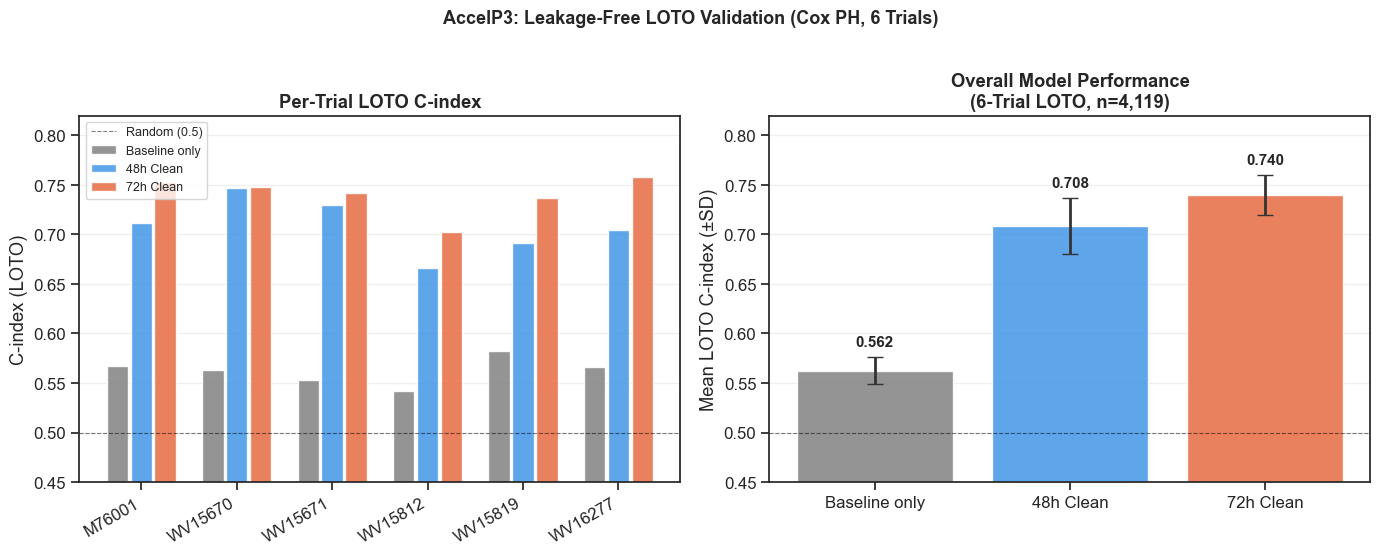

In [9]:
# ── Figure: per-trial bars + summary ──────────────────────────────────────
TRIAL_ORDER = ['M76001', 'WV15670', 'WV15671', 'WV15812', 'WV15819', 'WV16277']
MODELS = {
    'Baseline only': (res_baseline, '#888888'),
    '48h Clean':     (res_48h,      '#4C9BE8'),
    '72h Clean':     (res_72h,      '#E8734C'),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Left: per-trial grouped bars
ax = axes[0]
x      = np.arange(len(TRIAL_ORDER))
width  = 0.25
offsets = [-width, 0, width]

for i, (name, (res, color)) in enumerate(MODELS.items()):
    vals = [res.set_index('test_trial')['c_index'].get(t, np.nan) for t in TRIAL_ORDER]
    ax.bar(x + offsets[i], vals, width * 0.9, color=color, label=name, alpha=0.9, edgecolor='white')

ax.axhline(0.5, color='black', linestyle='--', linewidth=0.8, alpha=0.5, label='Random (0.5)')
ax.set_xticks(x)
ax.set_xticklabels(TRIAL_ORDER, rotation=30, ha='right')
ax.set_ylabel('C-index (LOTO)')
ax.set_title('Per-Trial LOTO C-index', fontweight='bold')
ax.set_ylim(0.45, 0.82)
ax.legend(fontsize=9, loc='upper left')
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)

# Right: summary bars with error bars
ax2 = axes[1]
names  = list(MODELS.keys())
means  = [res['c_index'].mean() for _, (res, _) in MODELS.items()]
sds    = [res['c_index'].std()  for _, (res, _) in MODELS.items()]
colors = [c for _, (_, c) in MODELS.items()]

bars = ax2.bar(names, means, yerr=sds, capsize=6, color=colors, alpha=0.9,
               edgecolor='white', error_kw={'linewidth': 2, 'ecolor': '#333333'})
ax2.axhline(0.5, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
for bar, mean, sd in zip(bars, means, sds):
    ax2.text(bar.get_x() + bar.get_width() / 2, mean + sd + 0.008,
             f'{mean:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax2.set_ylabel('Mean LOTO C-index (±SD)')
ax2.set_title(f'Overall Model Performance\n(6-Trial LOTO, n={len(feat_72h):,})', fontweight='bold')
ax2.set_ylim(0.45, 0.82)
ax2.yaxis.grid(True, alpha=0.3)
ax2.set_axisbelow(True)

plt.suptitle('AccelP3: Leakage-Free LOTO Validation (Cox PH, 6 Trials)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()

plt.show()


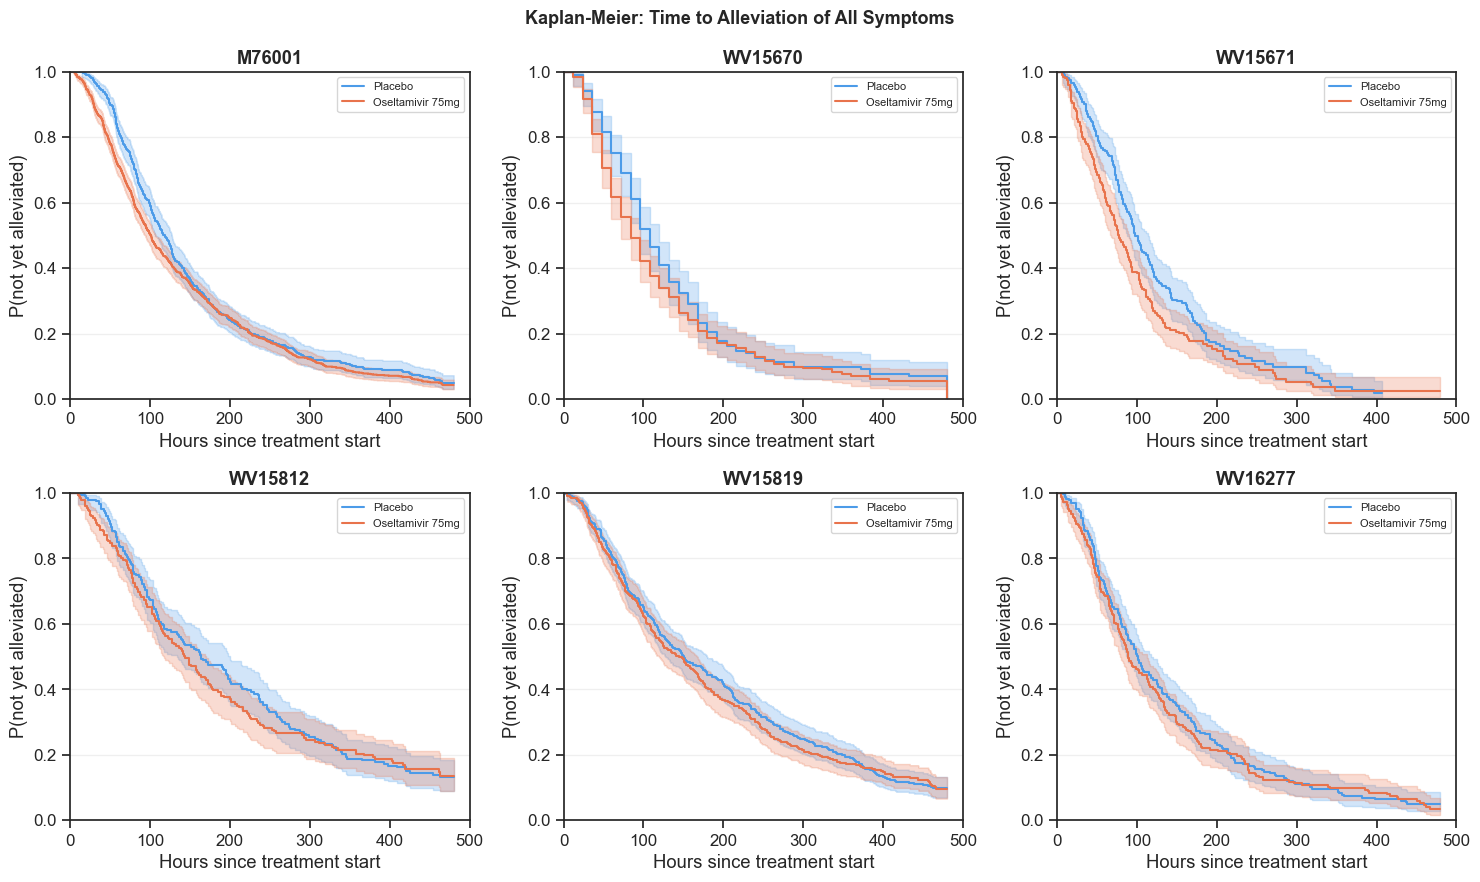

In [10]:
# ── KM curves: all 6 trials ────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, trial in enumerate(TRIAL_ORDER):
    ax = axes[i]
    df = master[master['trial_id'] == trial]

    for arm, color, label in [
        ('Placebo',          '#4C9BE8', 'Placebo'),
        ('Oseltamivir_75mg', '#E8734C', 'Oseltamivir 75mg'),
    ]:
        sub = df[df['treatment'] == arm]
        if len(sub) == 0:
            continue
        kmf = KaplanMeierFitter()
        kmf.fit(sub['tta_hours'], event_observed=sub['event'], label=label)
        kmf.plot_survival_function(ax=ax, ci_show=True, color=color)

    ax.set_title(trial, fontweight='bold')
    ax.set_xlabel('Hours since treatment start')
    ax.set_ylabel('P(not yet alleviated)')
    ax.set_xlim(0, 500)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8)
    ax.yaxis.grid(True, alpha=0.3)

plt.suptitle('Kaplan-Meier: Time to Alleviation of All Symptoms', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
